# 15 — Post-R8 diagnostics: E13, E14, E17-T1/T2 + arm derivations (spec v0.13; ZERO solves)

Runs in minutes. Ends by writing `spec/e_round_v13.json` — the E14 verdict (gates E15), the
E9/E10 arm derivations, and E17-T3's pre-stated expectations — which notebook 16 consumes.
Kernel `y2y-geo`.

**Pre-registered E15 trigger (frozen here):** E15 runs iff, in ≥1 formulation, ≥20% of the
51 members carry some value block below 0.95 × its anchor capture.

In [1]:
# ---- bootstrap + one streaming pass over the ensemble --------------------------------------
import importlib, json, pathlib, sys
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from pyproj import Transformer

_cands = [p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.py").exists()]
ROOT = _cands[0]
sys.path.insert(0, str(ROOT))
import config, leverage_core as lc, ensemble_core as ec
for _m in (config, lc, ec):
    importlib.reload(_m)

SPEC = ROOT / "analyses" / "y2y" / "spec"
RUNS = ROOT / "analyses" / "y2y" / "runs"
FIG = ROOT / "analyses" / "y2y" / "figures"
MAN = pd.read_csv(SPEC / "manifest.csv")
FORMS = list(MAN.formulation_id)
pu = lc.pu_mask()
with rasterio.open(config.HANDOFF_DIR / "mask_protected_areas.tif") as src:
    locked2d = (src.read(1) == 1) & pu
disc = ~locked2d[pu]

# feature value matrix V (n_pu x 8, share-normalized so S @ V = per-member captures)
cont = lc.continuous_features()
V = np.zeros((int(pu.sum()), len(cont)), dtype=np.float32)
RAWV = {}
for k, ft in enumerate(cont):
    v = lc._read(config.HANDOFF_DIR / f"{ft}.tif")
    RAWV[ft] = v
    vp = np.nan_to_num(v[pu], nan=0.0)
    V[:, k] = vp / vp.sum()

F_FORM, ANCHORS, MEMCAPS = {}, {}, {}
for c in FORMS:
    A = ec.read_selections(RUNS / c / "anchor.tif", pu)[0]
    M = ec.read_selections(RUNS / c / "mga_g05.tif", pu)
    S = np.vstack([A[None, :], M])
    F_FORM[c] = S.mean(axis=0).astype(np.float32)
    ANCHORS[c] = A
    MEMCAPS[c] = S.astype(np.float32) @ V          # 51 x 8 per-member captures
    del S, M
Fh = np.mean([F_FORM[c] for c in FORMS], axis=0)

# latitude of every PU cell (1-degree bands) -- ESRI:102008 is conic, so transform properly
with rasterio.open(config.HANDOFF_DIR / "cost_uniform.tif") as src:
    tr = src.transform
rows, cols = np.where(pu)
xs = tr.c + (cols + 0.5) * tr.a
ys = tr.f + (rows + 0.5) * tr.e
lon, lat = Transformer.from_crs(config.TARGET_CRS, "EPSG:4326", always_xy=True).transform(xs, ys)
LAT = lat.astype(np.float32)
BANDS = np.arange(np.floor(LAT.min()), np.ceil(LAT.max()) + 1)
band_of = np.digitize(LAT, BANDS)
print(f"loaded {len(FORMS)} formulations | lat {LAT.min():.1f}-{LAT.max():.1f}N | "
      f"{len(BANDS)-1} one-degree bands")

loaded 14 formulations | lat 41.8-67.3N | 27 one-degree bands


## E13 — frequency attribution: does high f sit on binding claims?

The Q2 mechanism test: overlay each high-f set (f ≥ 0.7) on the candidate binding-scarcity
masks. If the explanation holds, high-f cells concentrate in the m_soc θ-tail and (weakly)
the connectivity spike, NOT uniformly across valued layers — and the f-by-decile curves show
a spike-shaped fingerprint for targeted values vs flat curves for diffuse ones.

high-f set                    m_soc theta-tail          biomass theta-tailconnectivity spike (top 0.2%)    EFG presence (any of 40)
s0                                        4.7%                        0.0%                        1.1%                      100.0%
s2                                        3.9%                        0.0%                        4.0%                      100.0%
s4                                       80.8%                        0.5%                        0.3%                      100.0%
ensemble F                                7.1%                        0.0%                        1.1%                      100.0%


/var/folders/9r/qvrv12td3y9_rcssqr2csvbm0000gn/T/ipykernel_36145/1972997784.py:32: RuntimeWarning: Mean of empty slice
  ax.plot(range(10), [float(f[disc & (dec == d)].mean()) for d in range(10)],
/Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


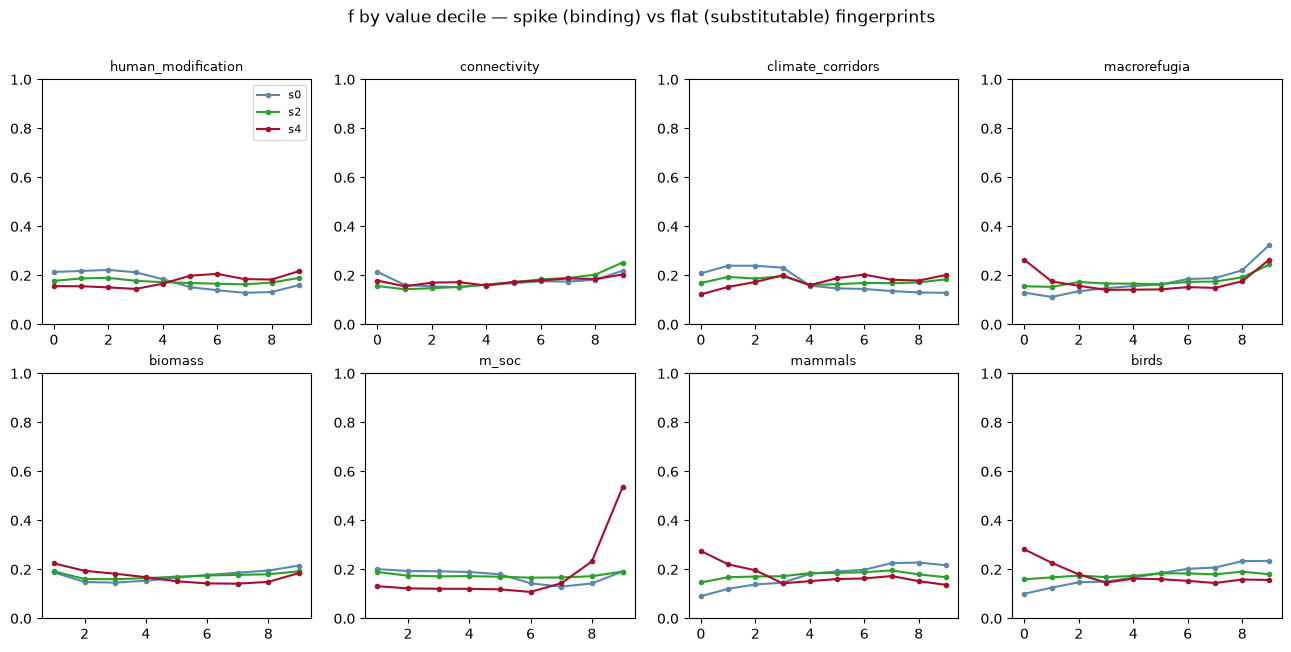


S2 sanity: manifest == formulation_meta weights; corridors w 2.303, connectivity w 1.316


In [2]:
theta = config.AUDIT["theta"]
masks = {}
for ft, nm in (("irrecoverable_carbon_m_soc", "m_soc theta-tail"),
               ("irrecoverable_carbon_biomass", "biomass theta-tail")):
    v = RAWV[ft]
    masks[nm] = (np.nan_to_num(v, nan=-1)[pu] >= theta * float(np.nanmean(v[pu])))
conn = RAWV["transboundary_connectivity"][pu]
masks["connectivity spike (top 0.2%)"] = conn >= np.nanquantile(conn, 0.998)
efg_pres = np.zeros(int(pu.sum()), bool)
for p_ in sorted((config.HANDOFF_DIR / "iucn_efg").glob("*.tif")):
    e = lc._read(p_)[pu]
    efg_pres |= np.nan_to_num(e, nan=0) > 0
masks["EFG presence (any of 40)"] = efg_pres

sets = {c: (F_FORM[c] >= 0.70) & disc for c in
        ("s0_ssp585_theta5", "s2_ssp585_theta5", "s4_ssp585_theta3")}
sets["ensemble F"] = (Fh >= 0.70) & disc
print(f"{'high-f set':<18}" + "".join(f"{nm:>28}" for nm in masks))
for sn, sm in sets.items():
    n = max(int(sm.sum()), 1)
    print(f"{sn.split('_')[0] if '_' in sn else sn:<18}" +
          "".join(f"{100*int((sm & mk).sum())/n:>27.1f}%" for mk in masks.values()))

# f-by-value-decile fingerprint
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, ft in zip(axes.ravel(), cont):
    vp = np.nan_to_num(RAWV[ft][pu], nan=0.0)
    dec = np.digitize(vp, np.quantile(vp[disc], np.linspace(0.1, 0.9, 9)))
    for sn, colr in (("s0_ssp585_theta5", "#5b87ad"), ("s2_ssp585_theta5", "#2ca02c"),
                     ("s4_ssp585_theta3", "#a50f2d")):
        f = F_FORM[sn]
        ax.plot(range(10), [float(f[disc & (dec == d)].mean()) for d in range(10)],
                marker="o", ms=3, color=colr, label=sn.split("_")[0])
    ax.set_title(ft.replace("irrecoverable_carbon_", "").replace("climate_type_", "")
                   .replace("aoh_richness_", "").replace("transboundary_", ""), fontsize=9)
    ax.set_ylim(0, 1)
axes[0, 0].legend(fontsize=8)
fig.suptitle("f by value decile — spike (binding) vs flat (substitutable) fingerprints")
fig.savefig(FIG / "e13_decile_fingerprints.png", dpi=170, bbox_inches="tight")
plt.show()

# S2 sanity: manifest weights == formulation_meta echo; realized influence recompute
row = MAN.set_index("formulation_id").loc["s2_ssp585_theta5"]
meta = json.loads((RUNS / "s2_ssp585_theta5" / "formulation_meta.json").read_text())
wm, wf = json.loads(row.weight_vector), meta["weight_vector"]
# meta is an R-written ECHO at jsonlite default 4 significant digits (solves used the
# full-precision manifest values); compare at echo precision
assert all(abs(wm[k] - wf[k]) < 1e-3 for k in wm), "S2 manifest/meta weight mismatch"
print("\nS2 sanity: manifest == formulation_meta weights; corridors w "
      f"{wm['climate_corridors']:.3f}, connectivity w {wm['transboundary_connectivity']:.3f}")

## E14 — is the aggregate band a de-facto per-value band?

Per-BLOCK capture spread across each formulation's 51 members vs its anchor. The frozen
trigger decides E15.

In [3]:
blocks = config.BLOCKS
bidx = {b: [cont.index(f) for f in fts] for b, fts in blocks.items()}
worst = []
trigger = False
for c in FORMS:
    caps = MEMCAPS[c]                      # 51 x 8
    anchor_caps = caps[0]
    frac_bad = np.zeros(51, bool)
    row = {"formulation": c}
    for b, ix in bidx.items():
        bc = caps[:, ix].sum(axis=1)
        floor = 0.95 * bc[0]
        row[b] = f"{bc.min():.3f}/{bc[0]:.3f}"
        frac_bad |= bc < floor
    share_bad = float(frac_bad[1:].mean())         # members only
    row["members_below_floor"] = f"{100*share_bad:.0f}%"
    worst.append(row)
    if share_bad >= 0.20:
        trigger = True
E14 = pd.DataFrame(worst).set_index("formulation")
print(E14.to_string())
print(f"\nE15 TRIGGER (>=20% members below a 0.95-anchor block floor in >=1 formulation): "
      f"{'FIRED -> run E15' if trigger else 'NOT FIRED -> E15 skipped'}")

                  core_habitat connectivity       carbon biodiversity members_below_floor
formulation                                                                              
s0_ssp585_theta5   0.360/0.452  0.579/0.594  0.603/0.642  0.623/0.657                100%
s1_ssp585_theta5   0.418/0.486  0.572/0.572  0.612/0.615  0.635/0.642                100%
s2_ssp585_theta5   0.336/0.420  0.593/0.670  0.590/0.632  0.607/0.629                100%
s3_ssp585_theta5   0.346/0.407  0.560/0.560  0.606/0.625  0.624/0.682                100%
s4_ssp585_theta3   0.343/0.418  0.601/0.605  0.806/0.881  0.591/0.618                100%
s5_ssp585_theta5   0.292/0.457  0.559/0.614  0.526/0.656  0.567/0.652                100%
s0_ssp245_theta5   0.364/0.428  0.584/0.587  0.611/0.638  0.629/0.663                100%
s1_ssp245_theta5   0.409/0.455  0.566/0.566  0.602/0.619  0.639/0.654                100%
s2_ssp245_theta5   0.338/0.401  0.598/0.666  0.594/0.623  0.611/0.632                100%
s3_ssp245_

## E17-T1/T2 — latitudinal attribution (zero-solve tiers)

Selection-vs-availability by 1° latitude band for every anchor + F, with the locked-PA
baseline separated (its own southern-parks/rock-and-ice bias must not be blamed on the
optimizer); per-feature latitudinal mass curves (the supply side of pull); rare-EFG footprint
geography.

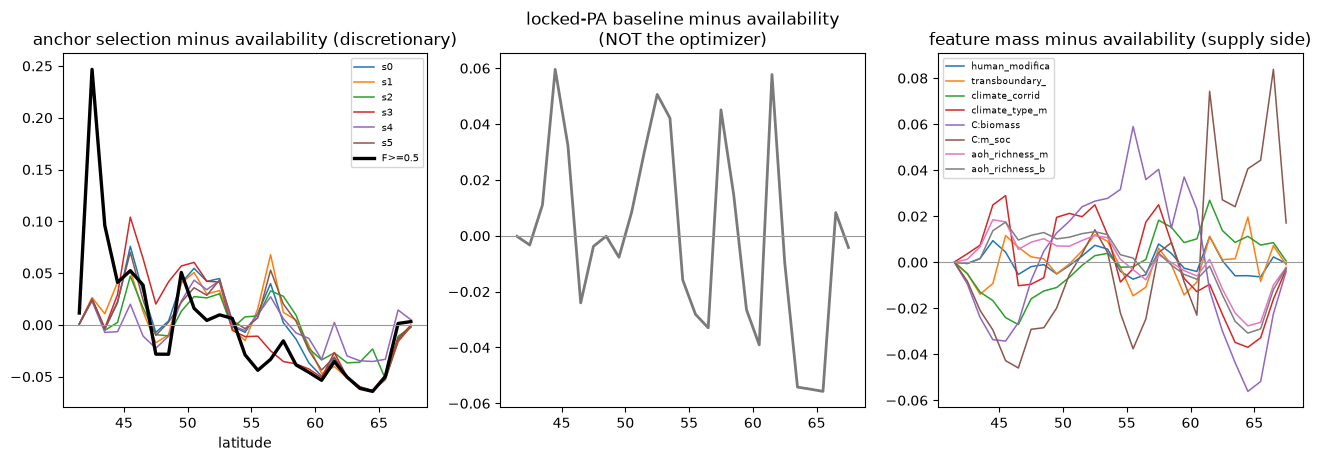

EFGs with >90% of footprint south of 53N: 20/40 | median EFG mean-latitude 48.6N
                efg  cells  south_share  mean_lat
  F2.3.web.mix_v2.0    222          1.0    42.367
  F1.4.web.map_v1.0     93          1.0    42.505
  F2.6.web.mix_v4.0      3          1.0    42.637
  F1.6.web.mix_v1.0   8215          1.0    42.652
 F3.4.web.orig_v1.0   5710          1.0    42.764
  F2.2.web.mix_v2.0      9          1.0    42.790
  T5.4.web.mix_v1.0   2234          1.0    43.934
SF2.2.web.orig_v1.0   5288          1.0    44.292


In [4]:
avail = np.array([(disc & (band_of == i)).sum() for i in range(1, len(BANDS))], float)
avail_share = avail / avail.sum()
def prof(sel):
    v = np.array([(sel & (band_of == i)).sum() for i in range(1, len(BANDS))], float)
    return v / max(v.sum(), 1)
pa_prof = prof(locked2d[pu])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
mid = (BANDS[:-1] + BANDS[1:]) / 2
for c in ("s0_ssp585_theta5", "s1_ssp585_theta5", "s2_ssp585_theta5",
          "s3_ssp585_theta5", "s4_ssp585_theta3", "s5_ssp585_theta5"):
    axes[0].plot(mid, prof(ANCHORS[c] & disc) - avail_share, lw=1.1, label=c.split("_")[0])
axes[0].plot(mid, prof((Fh >= 0.5) & disc) - avail_share, lw=2.4, color="black", label="F>=0.5")
axes[0].axhline(0, color="0.6", lw=0.8)
axes[0].set_title("anchor selection minus availability (discretionary)")
axes[0].set_xlabel("latitude"); axes[0].legend(fontsize=7)
axes[1].plot(mid, pa_prof - avail_share, color="#7a7a7a", lw=2)
axes[1].axhline(0, color="0.6", lw=0.8)
axes[1].set_title("locked-PA baseline minus availability\n(NOT the optimizer)")
for ft in cont:
    vp = np.nan_to_num(RAWV[ft][pu], nan=0.0)
    mass = np.array([vp[band_of == i].sum() for i in range(1, len(BANDS))])
    axes[2].plot(mid, mass / mass.sum() - avail_share, lw=1.1,
                 label=ft.replace("irrecoverable_carbon_", "C:")[:14])
axes[2].axhline(0, color="0.6", lw=0.8)
axes[2].set_title("feature mass minus availability (supply side)")
axes[2].legend(fontsize=6.5)
fig.savefig(FIG / "e17_latitude_profiles.png", dpi=170, bbox_inches="tight")
plt.show()

# T2: rare-EFG geography
south = LAT < 53.0
rows = []
for p_ in sorted((config.HANDOFF_DIR / "iucn_efg").glob("*.tif")):
    e = np.nan_to_num(lc._read(p_)[pu], nan=0) > 0
    if e.sum() == 0:
        continue
    rows.append(dict(efg=p_.stem, cells=int(e.sum()),
                     south_share=float(e[south].sum() / e.sum()),
                     mean_lat=float(LAT[e].mean())))
EFGGEO = pd.DataFrame(rows).sort_values("mean_lat")
n_south = int((EFGGEO.south_share > 0.9).sum())
print(f"EFGs with >90% of footprint south of 53N: {n_south}/{len(EFGGEO)} | "
      f"median EFG mean-latitude {EFGGEO.mean_lat.median():.1f}N")
print(EFGGEO.head(8).round(3).to_string(index=False))
EFGGEO.to_csv(SPEC / "e17_efg_geography.csv", index=False)

## Arm derivations + the E9 log layer → `spec/e_round_v13.json`

Everything notebook 16 needs: E9's two arms (weights-only; log-carbon with a derived
`log1p(m_soc)` layer, audited against the frozen screening), E10's θ-targets with re-derived
weights, E17-T3's pre-stated directional expectations, and the E14 verdict.

In [5]:
# E9 log layer: log1p(m_soc), PU-masked, OUTSIDE the manifest (per-run path patch)
v = RAWV["irrecoverable_carbon_m_soc"]
loga = np.where(pu, np.log1p(np.nan_to_num(v, nan=0.0)), np.nan).astype("float32")
from rasterio.io import MemoryFile
import rasterio.shutil as rio_shutil
with rasterio.open(config.HANDOFF_DIR / "cost_uniform.tif") as _s:
    PROF = dict(driver="GTiff", width=_s.width, height=_s.height, count=1, dtype="float32",
                crs=_s.crs, transform=_s.transform, nodata=_s.nodata)
out = config.HANDOFF_DIR / "e9_log_msoc.tif"
with MemoryFile() as mem:
    with mem.open(**PROF) as tmp:
        tmp.write(loga, 1)
        rio_shutil.copy(tmp, out, driver="COG", compress="DEFLATE",
                        overview_resampling="average", BIGTIFF="IF_SAFER")
cmin, cmax, lev = lc.leverage_of(loga[pu])
print(f"e9_log_msoc.tif: leverage {lev:.3f} (frozen screening said 0.486)")
assert abs(lev - 0.486) < 0.02, "log layer drifted from the frozen screening result"

sc = json.loads((SPEC / "scenarios_v2.json").read_text())
S0 = sc["S0_balanced"]
def wts(targets, layer_paths=None):
    d = lc.scenario_weights(S0["block_shares"], within_block=S0["within_block"],
                            targets=targets, layer_paths=layer_paths)
    return {r.feature: round(r.w, 6) for r in d.itertuples()}

payload = dict(
    created_utc=datetime.now(timezone.utc).isoformat(),
    e14=dict(trigger=bool(trigger), rule=">=20% of members below 0.95*anchor block capture in >=1 formulation"),
    e9=dict(
        infweights=dict(weights=wts({}), targets={}),
        logcarbon=dict(weights=wts({}, layer_paths={"irrecoverable_carbon_m_soc": out}),
                       targets={}, layer_patch={"irrecoverable_carbon_m_soc": "input_data/aligned_stack/e9_log_msoc.tif"}),
    ),
    e10=dict(
        theta10=dict(weights=wts({"irrecoverable_carbon_m_soc": 0.121}),
                     targets={"irrecoverable_carbon_m_soc": 0.121}),
        theta3=dict(weights=wts({"irrecoverable_carbon_m_soc": 0.552}),
                    targets={"irrecoverable_carbon_m_soc": 0.552}),
    ),
    e17_t3=dict(
        expectations={"biodiversity": "selection shifts NORTH (AOH mass is southern)",
                      "efg": "UNKNOWN -- that is the point of the run",
                      "carbon": "selection shifts SOUTH-of-current? pre-stated: south (tail is southern-interior)",
                      "core_habitat": "shifts toward richness/carbon country (refugia mass is northern-interior)",
                      "connectivity": "small shift (diffuse)"},
        blocks={b: fts for b, fts in config.BLOCKS.items()},
    ),
    e12=dict(formulations=["s0_ssp585_theta5", "s2_ssp585_theta5", "s4_ssp585_theta3"],
             k=50, g=0.05, seeds={"s0_ssp585_theta5": 20260902, "s2_ssp585_theta5": 20260903,
                                  "s4_ssp585_theta3": 20260904}),
)
(SPEC / "e_round_v13.json").write_text(json.dumps(payload, indent=2))
print(f"wrote spec/e_round_v13.json | E15 trigger: {trigger}")

e9_log_msoc.tif: leverage 0.487 (frozen screening said 0.486)
wrote spec/e_round_v13.json | E15 trigger: True
